Proje 2: Klasik SGD ve Adam Optimizasyon Algoritmalarının Karşılaştırılması
Bu çalışmada model eğitimi ve optimizasyon konusundaki anlattığım SGD ve ADAM algoritmalarını karşılaştıracağız.

1. Normalizasyon
Modelimizi 0-1 arasında bir değere koyarak normalize edeceğiz.

Veriler indirildi

 SGD
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8304 - loss: 0.6628 - val_accuracy: 0.9023 - val_loss: 0.3620
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9045 - loss: 0.3407 - val_accuracy: 0.9165 - val_loss: 0.2968
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9179 - loss: 0.2919 - val_accuracy: 0.9266 - val_loss: 0.2628
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9264 - loss: 0.2618 - val_accuracy: 0.9312 - val_loss: 0.2443
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9326 - loss: 0.2392 - val_accuracy: 0.9363 - val_loss: 0.2241

 ADAM
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9265 - loss: 0.2558 - val_accuracy: 0.9589 - val_loss: 0.1375
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9679 - loss: 0.1108 - val_accuracy: 0.9692 - val_loss: 0.1005
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy

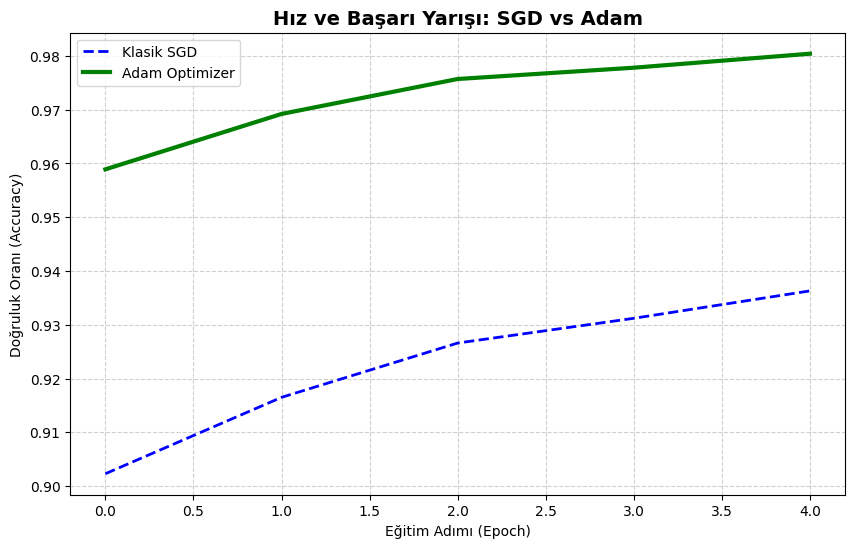

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

print("Veriler indirildi")
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0 # Normalizasyon

def model_olustur():
    return tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

# 2. EĞİTİM: SGD vs ADAM
print("\n SGD")
model_sgd = model_olustur()
model_sgd.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)

print("\n ADAM")
model_adam = model_olustur()
model_adam.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=1)

plt.figure(figsize=(10, 6))
plt.plot(history_sgd.history['val_accuracy'], label='Klasik SGD', color='blue', linewidth=2, linestyle='--')
plt.plot(history_adam.history['val_accuracy'], label='Adam Optimizer', color='green', linewidth=3)
plt.title("Hız ve Başarı Yarışı: SGD vs Adam", fontsize=14, fontweight='bold')
plt.xlabel("Eğitim Adımı (Epoch)")
plt.ylabel("Doğruluk Oranı (Accuracy)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()